First 5 rows of the dataset:
   year  chinese_code     name        landfall_time  landfall_lat  \
0  1960          6001     Mary  1960-06-08 18:00:00     22.148900   
1  1960          6007  Shirley  1960-07-31 18:00:00     24.672577   
2  1960          6024      Kit  1960-10-11 12:00:00     19.489094   
3  1961          6109    Doris  1961-07-02 00:00:00     23.421863   
4  1961          6110    Elsie  1961-07-15 00:00:00     23.220733   

   landfall_lon  landfall_wind_speed  landfall_pressure  \
0    113.886675                 35.0              970.0   
1    121.830653                 50.0              950.0   
2    110.807887                 35.0              980.0   
3    116.833602                 20.0              986.0   
4    116.677436                 15.0              992.0   

   landfall_wind_category  max_wind  ...  landfall_date month        date  \
0                       2      45.0  ...     1960-06-08     6  1960-06-08   
1                       2      70.0  ...     19

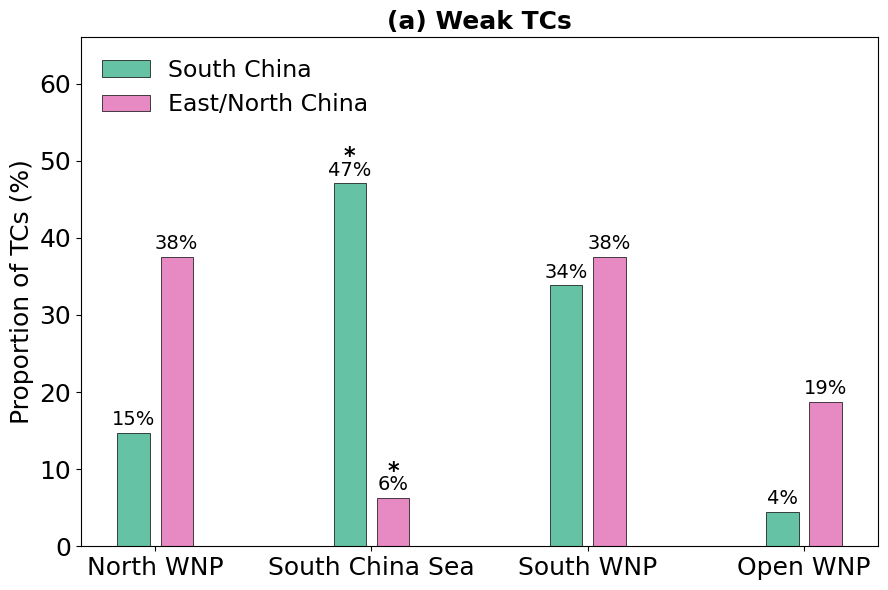

Panel b: Moderate/Super TCs - grouped by landfall region, formation region proportions and significance tests
Total TCs sample size: 174

Total typhoons per landfall region:
south China         108
east/north China     66
Name: landfall_region, dtype: int64

Counts per cell:
[[ 6 13]
 [12  0]
 [50 22]
 [40 31]]

Proportions per cell (relative to landfall region total):
[[0.05555556 0.1969697 ]
 [0.11111111 0.        ]
 [0.46296296 0.33333333]
 [0.37037037 0.46969697]]

Overall south China proportion: 0.621
Overall east/north China proportion: 0.379

Detailed Bootstrap significance test results:
  formation_region   landfall_region  observed_prop  ci_lower  ci_upper  \
0        North WNP       South China       0.315789  0.421053  0.789474   
1        North WNP  East/North China       0.684211  0.210526  0.578947   
2  South China Sea       South China       1.000000  0.416667  0.833333   
3  South China Sea  East/North China       0.000000  0.166667  0.583333   
4        South WNP     

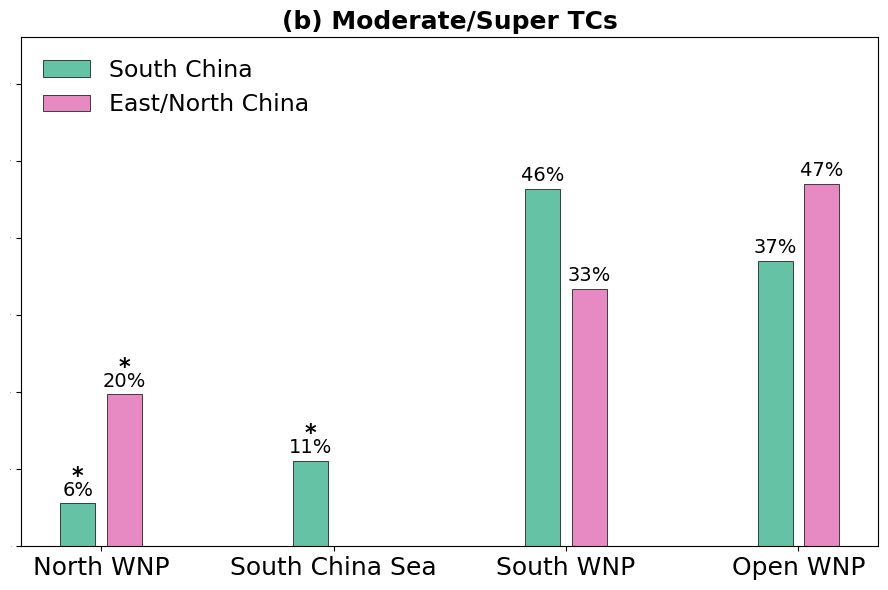

Panel c: Weak TCs - grouped by formation region, MJO phase group proportions and significance tests
Total Storms sample size: 84

Total typhoons per formation region:
South China Sea    33
South WNP          29
North WNP          16
Open WNP            6
Name: formation_region, dtype: int64

Counts per cell:
[[ 3  3  5  5]
 [ 3  6 18  6]
 [ 9  5 11  4]
 [ 0  1  2  3]]

Proportions per cell (relative to formation region total):
[[0.1875     0.1875     0.3125     0.3125    ]
 [0.09090909 0.18181818 0.54545455 0.18181818]
 [0.31034483 0.17241379 0.37931034 0.13793103]
 [0.         0.16666667 0.33333333 0.5       ]]

Overall proportion of each MJO phase group:
Phases 1-2: 0.179
Phases 3-4: 0.179
Phases 5-6: 0.429
Phases 7-8: 0.214

Detailed Bootstrap significance test results:
   formation_region   mjo_group  observed_prop  ci_lower  ci_upper  p_value  \
0         North WNP  Phases 1-2       0.187500  0.062500  0.312500    1.148   
1         North WNP  Phases 3-4       0.187500  0.062500  

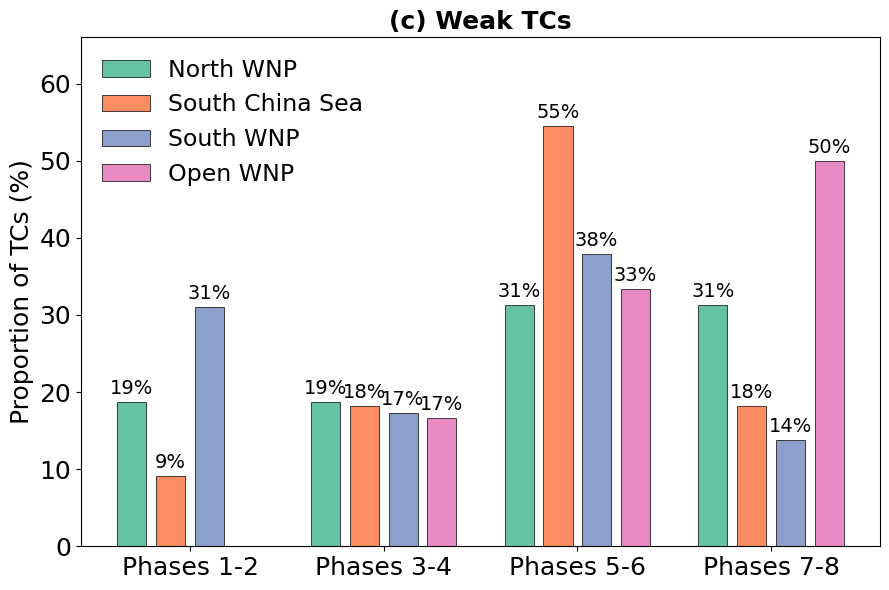

Panel d: Moderate/Super TCs - grouped by formation region, MJO phase group proportions and significance tests
Total TCs sample size: 174

Total typhoons per formation region:
South WNP          72
Open WNP           71
North WNP          19
South China Sea    12
Name: formation_region, dtype: int64

Counts per cell:
[[ 8  4  4  3]
 [ 1  1  7  3]
 [ 8 13 35 16]
 [ 9 11 36 15]]

Proportions per cell (relative to formation region total):
[[0.42105263 0.21052632 0.21052632 0.15789474]
 [0.08333333 0.08333333 0.58333333 0.25      ]
 [0.11111111 0.18055556 0.48611111 0.22222222]
 [0.12676056 0.15492958 0.50704225 0.21126761]]

Overall proportion of each MJO phase group:
Phases 1-2: 0.149
Phases 3-4: 0.167
Phases 5-6: 0.471
Phases 7-8: 0.213

Detailed Bootstrap significance test results:
   formation_region   mjo_group  observed_prop  ci_lower  ci_upper  p_value  \
0         North WNP  Phases 1-2       0.421053  0.000000  0.315789    0.006   
1         North WNP  Phases 3-4       0.210526  0.

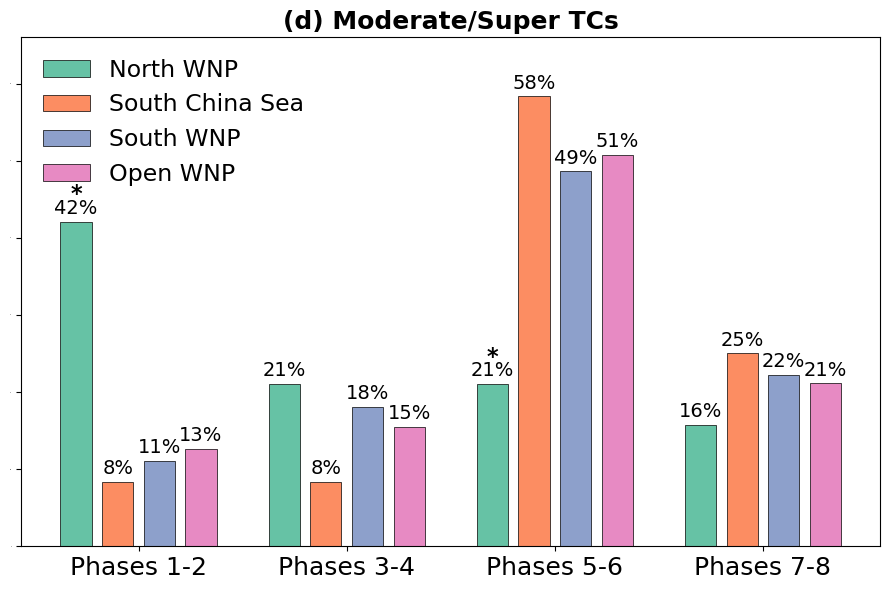

All figures have been drawn and saved as PNG files.


In [3]:
# %%
"""
Analysis of Typhoon Landfall Formation Region Dataset
This code analyzes the typhoon dataset and generates four bar charts:
- Panel a: Weak TCs, grouped by landfall region, showing the proportion of each formation region, with Bootstrap significance tests.
- Panel b: Moderate/Super TCs, grouped by landfall region, showing the proportion of each formation region, with Bootstrap significance tests.
- Panel c: Weak TCs, grouped by formation region, showing the proportion of each MJO phase group, with Bootstrap significance tests.
- Panel d: Moderate/Super TCs, grouped by formation region, showing the proportion of each MJO phase group, with Bootstrap significance tests.
"""

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

 

# %%
# 1. Load data
file_path = './typhoon_output/landfall_typhoons_with_region.csv'
df = pd.read_csv(file_path)

# Display basic data information
print("First 5 rows of the dataset:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nMissing values statistics:")
print(df.isnull().sum())
print("\nUnique value count per column:")
print(df.nunique())

# %%
# 2. Data preprocessing
# Ensure phase is integer, and define MJO phase groups
df['phase'] = df['phase'].astype(int)

def mjo_phase_group(phase):
    """Merge MJO phases (1–8) into four groups"""
    if phase in [1, 2]:
        return 'Phases 1-2'
    elif phase in [3, 4]:
        return 'Phases 3-4'
    elif phase in [5, 6]:
        return 'Phases 5-6'
    elif phase in [7, 8]:
        return 'Phases 7-8'
    else:
        return np.nan

df['mjo_group'] = df['phase'].apply(mjo_phase_group)

# Check for invalid phases
print("\nDistribution after MJO phase grouping:")
print(df['mjo_group'].value_counts())

# Define category order for formation region and landfall region (to maintain order in plots)
formation_order = ['North WNP', 'South China Sea', 'South WNP', 'Open WNP']
# ===== Modification 1: change landfall_order to the desired capitalization format =====
landfall_order = ['South China', 'East/North China']
mjo_order = ['Phases 1-2', 'Phases 3-4', 'Phases 5-6', 'Phases 7-8']

# Define colors (according to the given color mapping)
formation_colors = {
    'North WNP': '#66c2a5',
    'South China Sea': '#fc8d62',
    'South WNP': '#8da0cb',
    'Open WNP': '#e78ac3'
}
# ===== Modification 2: keys of landfall_colors match landfall_order =====
landfall_colors = {
    'South China': '#66c2a5',
    'East/North China': '#e78ac3'
}

# ===== New: mapping from display label to original value in the dataset =====
landfall_original = {
    'South China': 'south China',
    'East/North China': 'east/north China'
}

# %%
# 3. Define Bootstrap significance test function
def bootstrap_test(group_success, group_total, overall_success, overall_total, n_iter=1000, alpha=0.1):
    """
    Perform Bootstrap significance test for a group proportion.
    Parameters:
        group_success: number of successes in the subgroup
        group_total: total sample size in the subgroup
        overall_success: number of successes in the overall population
        overall_total: total sample size of the overall population
        n_iter: number of bootstrap iterations
        alpha: significance level (two-tailed, so confidence level is 1-alpha)
    Returns:
        observed_prop: observed proportion
        ci_lower: lower bound of confidence interval
        ci_upper: upper bound of confidence interval
        p_value: two-tailed p-value
        significant: whether the result is significant (True/False)
    """
    observed_prop = group_success / group_total if group_total > 0 else 0
    # Overall proportion (used to generate bootstrap samples)
    overall_prop = overall_success / overall_total if overall_total > 0 else 0
    # Simulate drawing group_total samples from the population and compute proportion
    bootstrap_props = []
    for _ in range(n_iter):
        # Randomly draw group_total samples with replacement from the population,
        # each with success probability overall_prop.
        # Using binomial distribution simulation, equivalent to np.random.binomial(group_total, overall_prop) / group_total
        sample_success = np.random.binomial(group_total, overall_prop)
        bootstrap_props.append(sample_success / group_total)
    bootstrap_props = np.array(bootstrap_props)
    # Compute two-tailed confidence interval (percentile method)
    ci_lower = np.percentile(bootstrap_props, 100 * alpha / 2)
    ci_upper = np.percentile(bootstrap_props, 100 * (1 - alpha / 2))
    # Compute p-value: twice the frequency of the observed value falling outside the distribution
    p_lower = np.mean(bootstrap_props <= observed_prop)
    p_upper = np.mean(bootstrap_props >= observed_prop)
    p_value = 2 * min(p_lower, p_upper)
    significant = (observed_prop < ci_lower) or (observed_prop > ci_upper)
    return observed_prop, ci_lower, ci_upper, p_value, significant

# %%
# 4. Define plotting function (generic grouped bar chart, supports two or more sub-groups)
# ===== Modification: add three independent control parameters and control tick labels separately =====
def plot_grouped_bars(data, x_labels, group_labels, values, colors, 
                      ylabel='Proportion (%)', title='', 
                      width=0.15, gap=0.05, y_max=60, 
                      significance=None, filename=None,
                      show_xlabel=True,    # separately control x-axis label display
                      show_ylabel=True,    # separately control y-axis label display
                      show_title=True,     # separately control title display
                      show_xticklabels=True,   # separately control x-tick label display
                      show_yticklabels=True):  # separately control y-tick label display

    n_groups = len(x_labels)          # number of groups on x-axis
    n_cats = len(group_labels)        # number of bars within each group
    
    # Calculate offset for each bar so that bars are centered around the group center
    total_width_per_group = n_cats * width + (n_cats - 1) * gap
    start_offset = - (total_width_per_group - width) / 2
    offsets = [start_offset + i * (width + gap) for i in range(n_cats)]
    
    fig, ax = plt.subplots(figsize=(9, 6))
    x = np.arange(n_groups)  # group center positions
    
    col_counter = 1  # bar counter (for asterisk annotation, but here we directly use the significance matrix)
    for i, cat in enumerate(group_labels):
        # values of this category across groups
        vals = data[i, :] * 100  # convert to percentage
        # bar positions
        bar_positions = x + offsets[i]
        bars = ax.bar(bar_positions, vals, width,
                      color=colors[i],
                      edgecolor='black', linewidth=0.5,
                      label=cat)
        
        # Annotate percentage at the top of each bar (integer, only if >0)
        for j, (bar, val) in enumerate(zip(bars, vals)):
            if val > 0:
                x_center = bar.get_x() + bar.get_width() / 2
                y_base = bar.get_height()
                ax.text(x_center, y_base + 0.5, f'{val:.0f}%', 
                        ha='center', va='bottom', fontsize=14)
                # If significant, add an asterisk
                if significance is not None and significance[i, j]:
                    ax.text(x_center, y_base + 2, '*', 
                            ha='center', va='bottom', fontsize=16, fontweight='bold', color='black')
    
    # Set x-axis ticks
    ax.set_xticks(x)
    # ===== Modification: decide whether to show x-axis label text based on show_xlabel =====
    if show_xlabel:
        ax.set_xticklabels(x_labels, fontsize=18)
        ax.set_xlabel('')
    else:
        ax.set_xticklabels([])  # do not show x-axis label text
    
    # ===== Modification: decide whether to show y-axis label based on show_ylabel =====
    if show_ylabel:
        ax.set_ylabel(ylabel, fontsize=18)
    else:
        ax.set_ylabel('')  # do not show y-axis label
    
    # ===== Modification: decide whether to show title based on show_title =====
    if show_title:
        ax.set_title(title, fontsize=18, fontweight='bold')
    else:
        ax.set_title('')   # do not show title
    
    ax.legend(fontsize=17, loc='upper left', frameon=False)
    ax.set_ylim(0, y_max * 1.1 if y_max else 70)  # leave some space
    
    # ===== Modification: separately control x-tick and y-tick label display =====
    # Set x-axis tick label size; if show_xticklabels is False, hide them
    if show_xticklabels:
        ax.tick_params(axis='x', labelsize=18)
    else:
        ax.tick_params(axis='x', labelsize=0)  # hide x-tick labels
    
    # Set y-axis tick label size; if show_yticklabels is False, hide them
    if show_yticklabels:
        ax.tick_params(axis='y', labelsize=18)
    else:
        ax.tick_params(axis='y', labelsize=0)  # hide y-tick labels
    
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color('black')
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=600, bbox_inches='tight')
    plt.show()

# %%
# 5. Define the overall dataset (used for Bootstrap testing)
# We will compute the overall proportion within each category (Storms/TCs),
# so the overall population is the corresponding filtered dataset

# %%
# Panel a: Weak TCs, grouped by landfall region, showing formation region proportions
print("="*80)
print("Panel a: Weak TCs - grouped by landfall region, formation region proportions and significance tests")
print("="*80)

# Filter for Storms
storms_df = df[df['typhoon_category'] == 'Storms'].copy()
print(f"Total Storms sample size: {len(storms_df)}")

# Calculate total typhoons per landfall region (note: still use original values in the data)
landfall_counts = storms_df['landfall_region'].value_counts()
print("\nTotal typhoons per landfall region:")
print(landfall_counts)

# Calculate the count and proportion of each formation region within each landfall region
# Build a matrix: rows are formation regions (4), columns are landfall regions (2), values are proportions (relative to landfall region)
# Also record the sample count for each cell for Bootstrap tests
proportions = np.zeros((len(formation_order), len(landfall_order)))
counts = np.zeros((len(formation_order), len(landfall_order)), dtype=int)
total_by_landfall = {region: landfall_counts.get(landfall_original[region], 0) for region in landfall_order}  # Modified: use mapping to get total for original value

for i, f_region in enumerate(formation_order):
    for j, l_region_display in enumerate(landfall_order):
        l_region_original = landfall_original[l_region_display]  # get original value
        # Count typhoons with this formation region and landfall region
        sub_df = storms_df[(storms_df['formation_region'] == f_region) & (storms_df['landfall_region'] == l_region_original)]
        cnt = len(sub_df)
        counts[i, j] = cnt
        total = total_by_landfall[l_region_display]
        prop = cnt / total if total > 0 else 0
        proportions[i, j] = prop

print("\nCounts per cell:")
print(counts)
print("\nProportions per cell (relative to landfall region total):")
print(proportions)

# Bootstrap significance test
# Overall proportion of south China = landfall_counts['south China'] / len(storms_df)
overall_prop_south = landfall_counts.get('south China', 0) / len(storms_df)
overall_prop_east = landfall_counts.get('east/north China', 0) / len(storms_df)

print(f"\nOverall south China proportion: {overall_prop_south:.3f}")
print(f"Overall east/north China proportion: {overall_prop_east:.3f}")

# Perform Bootstrap test for each formation_region
bootstrap_results = []
for i, f_region in enumerate(formation_order):
    # Total sample size of this formation region
    region_total = len(storms_df[storms_df['formation_region'] == f_region])
    # Number of south China landfalls in this formation region (use mapping to find column index)
    south_cnt = counts[i, landfall_order.index('South China')]
    east_cnt = counts[i, landfall_order.index('East/North China')]
    
    # Test south China proportion
    if region_total > 0:
        obs_prop_south = south_cnt / region_total
        obs_prop_east = east_cnt / region_total
    else:
        obs_prop_south = obs_prop_east = 0
    
    # Bootstrap for south China
    if region_total > 0:
        obs, ci_l, ci_u, p, sig = bootstrap_test(south_cnt, region_total, 
                                                  landfall_counts.get('south China', 0), len(storms_df))
        bootstrap_results.append({
            'formation_region': f_region,
            'landfall_region': 'South China',  # store display label
            'observed_prop': obs,
            'ci_lower': ci_l,
            'ci_upper': ci_u,
            'p_value': p,
            'significant': sig
        })
    
    # Bootstrap for east/north China
    if region_total > 0:
        obs, ci_l, ci_u, p, sig = bootstrap_test(east_cnt, region_total,
                                                  landfall_counts.get('east/north China', 0), len(storms_df))
        bootstrap_results.append({
            'formation_region': f_region,
            'landfall_region': 'East/North China',  # store display label
            'observed_prop': obs,
            'ci_lower': ci_l,
            'ci_upper': ci_u,
            'p_value': p,
            'significant': sig
        })

# Print Bootstrap results
results_df = pd.DataFrame(bootstrap_results)
print("\nDetailed Bootstrap significance test results:")
print(results_df)

# Build significance matrix for plotting (same shape as proportions)
sig_matrix = np.zeros_like(proportions, dtype=bool)
for _, row in results_df.iterrows():
    i = formation_order.index(row['formation_region'])
    j = landfall_order.index(row['landfall_region'])
    sig_matrix[i, j] = row['significant']

# Draw Panel a (show all labels)
plot_data = proportions.T  # transposed shape (2, 4)
plot_colors = [landfall_colors[region] for region in landfall_order]
plot_significance = sig_matrix.T  # transposed shape (2, 4)

plot_grouped_bars(
    data=plot_data,
    x_labels=formation_order,
    group_labels=landfall_order,  # use new display labels
    values=plot_data,
    colors=plot_colors,
    ylabel='Proportion of TCs (%)',
    title='(a) Weak TCs',
    width=0.15,
    gap=0.05,
    y_max=60,
    significance=plot_significance,
    filename='8a.png',
    show_xlabel=True,        # show x-axis label
    show_ylabel=True,        # show y-axis label
    show_title=True,         # show title
    show_xticklabels=True,   # show x-tick labels
    show_yticklabels=True    # show y-tick labels
)

# %%
# Panel b: Moderate/Super TCs, grouped by landfall region, showing formation region proportions
print("="*80)
print("Panel b: Moderate/Super TCs - grouped by landfall region, formation region proportions and significance tests")
print("="*80)

# Filter for TCs
tcs_df = df[df['typhoon_category'] == 'TCs'].copy()
print(f"Total TCs sample size: {len(tcs_df)}")

# Total counts per landfall region (original values)
landfall_counts_tcs = tcs_df['landfall_region'].value_counts()
print("\nTotal typhoons per landfall region:")
print(landfall_counts_tcs)

# Build proportion and count matrices
proportions_tcs = np.zeros((len(formation_order), len(landfall_order)))
counts_tcs = np.zeros((len(formation_order), len(landfall_order)), dtype=int)
total_by_landfall_tcs = {region: landfall_counts_tcs.get(landfall_original[region], 0) for region in landfall_order}

for i, f_region in enumerate(formation_order):
    for j, l_region_display in enumerate(landfall_order):
        l_region_original = landfall_original[l_region_display]
        sub_df = tcs_df[(tcs_df['formation_region'] == f_region) & (tcs_df['landfall_region'] == l_region_original)]
        cnt = len(sub_df)
        counts_tcs[i, j] = cnt
        total = total_by_landfall_tcs[l_region_display]
        prop = cnt / total if total > 0 else 0
        proportions_tcs[i, j] = prop

print("\nCounts per cell:")
print(counts_tcs)
print("\nProportions per cell (relative to landfall region total):")
print(proportions_tcs)

# Bootstrap significance test
overall_total_tcs = len(tcs_df)
overall_prop_south_tcs = landfall_counts_tcs.get('south China', 0) / overall_total_tcs
overall_prop_east_tcs = landfall_counts_tcs.get('east/north China', 0) / overall_total_tcs
print(f"\nOverall south China proportion: {overall_prop_south_tcs:.3f}")
print(f"Overall east/north China proportion: {overall_prop_east_tcs:.3f}")

bootstrap_results_tcs = []
for i, f_region in enumerate(formation_order):
    region_total = len(tcs_df[tcs_df['formation_region'] == f_region])
    south_cnt = counts_tcs[i, landfall_order.index('South China')]
    east_cnt = counts_tcs[i, landfall_order.index('East/North China')]
    
    if region_total > 0:
        # south China
        obs, ci_l, ci_u, p, sig = bootstrap_test(south_cnt, region_total,
                                                  landfall_counts_tcs.get('south China', 0), overall_total_tcs)
        bootstrap_results_tcs.append({
            'formation_region': f_region,
            'landfall_region': 'South China',
            'observed_prop': obs,
            'ci_lower': ci_l,
            'ci_upper': ci_u,
            'p_value': p,
            'significant': sig
        })
        # east/north China
        obs, ci_l, ci_u, p, sig = bootstrap_test(east_cnt, region_total,
                                                  landfall_counts_tcs.get('east/north China', 0), overall_total_tcs)
        bootstrap_results_tcs.append({
            'formation_region': f_region,
            'landfall_region': 'East/North China',
            'observed_prop': obs,
            'ci_lower': ci_l,
            'ci_upper': ci_u,
            'p_value': p,
            'significant': sig
        })

results_df_tcs = pd.DataFrame(bootstrap_results_tcs)
print("\nDetailed Bootstrap significance test results:")
print(results_df_tcs)

sig_matrix_tcs = np.zeros_like(proportions_tcs, dtype=bool)
for _, row in results_df_tcs.iterrows():
    i = formation_order.index(row['formation_region'])
    j = landfall_order.index(row['landfall_region'])
    sig_matrix_tcs[i, j] = row['significant']

plot_data_tcs = proportions_tcs.T
plot_significance_tcs = sig_matrix_tcs.T

plot_grouped_bars(
    data=plot_data_tcs,
    x_labels=formation_order,
    group_labels=landfall_order,  # use new display labels
    values=plot_data_tcs,
    colors=plot_colors,  # same colors as Panel a (landfall region colors)
    ylabel='Proportion of TCs (%)',
    title='(b) Moderate/Super TCs',
    width=0.15,
    gap=0.05,
    y_max=60,
    significance=plot_significance_tcs,
    filename='8b.png',
    show_xlabel=True,        # show x-axis label
    show_ylabel=False,       # show y-axis label
    show_title=True,         # show title
    show_xticklabels=True,   # show x-tick labels
    show_yticklabels=False   # show y-tick labels
)

# %%
# Panel c: Weak TCs, grouped by formation region, showing MJO phase group proportions
print("="*80)
print("Panel c: Weak TCs - grouped by formation region, MJO phase group proportions and significance tests")
print("="*80)

storms_df = df[df['typhoon_category'] == 'Storms'].copy()
print(f"Total Storms sample size: {len(storms_df)}")

# Calculate total typhoons per formation region
formation_counts_storms = storms_df['formation_region'].value_counts()
print("\nTotal typhoons per formation region:")
print(formation_counts_storms)

# Build proportion matrix: rows are formation regions (4), columns are MJO phase groups (4),
# values are the proportion of each MJO phase within that formation region
proportions_storms_mjo = np.zeros((len(formation_order), len(mjo_order)))
counts_storms_mjo = np.zeros((len(formation_order), len(mjo_order)), dtype=int)

for i, f_region in enumerate(formation_order):
    for j, mjo_group in enumerate(mjo_order):
        sub_df = storms_df[(storms_df['formation_region'] == f_region) & (storms_df['mjo_group'] == mjo_group)]
        cnt = len(sub_df)
        counts_storms_mjo[i, j] = cnt
        total = formation_counts_storms.get(f_region, 0)
        prop = cnt / total if total > 0 else 0
        proportions_storms_mjo[i, j] = prop

print("\nCounts per cell:")
print(counts_storms_mjo)
print("\nProportions per cell (relative to formation region total):")
print(proportions_storms_mjo)

# Bootstrap significance test
# Overall population: all Storms, proportion of each MJO phase group
overall_mjo_counts = storms_df['mjo_group'].value_counts()
overall_total_storms = len(storms_df)
overall_mjo_props = {group: overall_mjo_counts.get(group, 0) / overall_total_storms for group in mjo_order}
print("\nOverall proportion of each MJO phase group:")
for g in mjo_order:
    print(f"{g}: {overall_mjo_props[g]:.3f}")

# Bootstrap test for each formation region–phase group combination
bootstrap_results_storms_mjo = []
for i, f_region in enumerate(formation_order):
    region_total = formation_counts_storms.get(f_region, 0)
    if region_total == 0:
        continue
    for j, mjo_group in enumerate(mjo_order):
        cnt = counts_storms_mjo[i, j]
        obs_prop = cnt / region_total if region_total > 0 else 0
        # Draw region_total samples from the population; test the proportion of this phase group
        obs, ci_l, ci_u, p, sig = bootstrap_test(cnt, region_total,
                                                  overall_mjo_counts.get(mjo_group, 0), overall_total_storms)
        bootstrap_results_storms_mjo.append({
            'formation_region': f_region,
            'mjo_group': mjo_group,
            'observed_prop': obs,
            'ci_lower': ci_l,
            'ci_upper': ci_u,
            'p_value': p,
            'significant': sig
        })

results_storms_mjo_df = pd.DataFrame(bootstrap_results_storms_mjo)
print("\nDetailed Bootstrap significance test results:")
print(results_storms_mjo_df)

# Build significance matrix (same shape as proportions_storms_mjo)
sig_matrix_storms_mjo = np.zeros_like(proportions_storms_mjo, dtype=bool)
for _, row in results_storms_mjo_df.iterrows():
    i = formation_order.index(row['formation_region'])
    j = mjo_order.index(row['mjo_group'])
    sig_matrix_storms_mjo[i, j] = row['significant']

# Draw Panel c (each element display can be controlled individually)
plot_data_c = proportions_storms_mjo  # shape (4,4)
plot_colors_c = [formation_colors[region] for region in formation_order]
plot_significance_c = sig_matrix_storms_mjo

plot_grouped_bars(
    data=plot_data_c,
    x_labels=mjo_order,
    group_labels=formation_order,
    values=plot_data_c,
    colors=plot_colors_c,
    ylabel='Proportion of TCs (%)',
    title='(c) Weak TCs',
    width=0.15,
    gap=0.05,
    y_max=60,
    significance=plot_significance_c,
    filename='8c.png',
    show_xlabel=True,        # hide x-axis label
    show_ylabel=True,        # hide y-axis label
    show_title=True,         # hide title
    show_xticklabels=True,   # hide x-tick labels
    show_yticklabels=True    # hide y-tick labels
)

# %%
# Panel d: Moderate/Super TCs, grouped by formation region, showing MJO phase group proportions
print("="*80)
print("Panel d: Moderate/Super TCs - grouped by formation region, MJO phase group proportions and significance tests")
print("="*80)

tcs_df = df[df['typhoon_category'] == 'TCs'].copy()
print(f"Total TCs sample size: {len(tcs_df)}")

formation_counts_tcs = tcs_df['formation_region'].value_counts()
print("\nTotal typhoons per formation region:")
print(formation_counts_tcs)

proportions_tcs_mjo = np.zeros((len(formation_order), len(mjo_order)))
counts_tcs_mjo = np.zeros((len(formation_order), len(mjo_order)), dtype=int)

for i, f_region in enumerate(formation_order):
    for j, mjo_group in enumerate(mjo_order):
        sub_df = tcs_df[(tcs_df['formation_region'] == f_region) & (tcs_df['mjo_group'] == mjo_group)]
        cnt = len(sub_df)
        counts_tcs_mjo[i, j] = cnt
        total = formation_counts_tcs.get(f_region, 0)
        prop = cnt / total if total > 0 else 0
        proportions_tcs_mjo[i, j] = prop

print("\nCounts per cell:")
print(counts_tcs_mjo)
print("\nProportions per cell (relative to formation region total):")
print(proportions_tcs_mjo)

# Bootstrap significance test
overall_mjo_counts_tcs = tcs_df['mjo_group'].value_counts()
overall_total_tcs = len(tcs_df)
overall_mjo_props_tcs = {group: overall_mjo_counts_tcs.get(group, 0) / overall_total_tcs for group in mjo_order}
print("\nOverall proportion of each MJO phase group:")
for g in mjo_order:
    print(f"{g}: {overall_mjo_props_tcs[g]:.3f}")

bootstrap_results_tcs_mjo = []
for i, f_region in enumerate(formation_order):
    region_total = formation_counts_tcs.get(f_region, 0)
    if region_total == 0:
        continue
    for j, mjo_group in enumerate(mjo_order):
        cnt = counts_tcs_mjo[i, j]
        obs_prop = cnt / region_total if region_total > 0 else 0
        obs, ci_l, ci_u, p, sig = bootstrap_test(cnt, region_total,
                                                  overall_mjo_counts_tcs.get(mjo_group, 0), overall_total_tcs)
        bootstrap_results_tcs_mjo.append({
            'formation_region': f_region,
            'mjo_group': mjo_group,
            'observed_prop': obs,
            'ci_lower': ci_l,
            'ci_upper': ci_u,
            'p_value': p,
            'significant': sig
        })

results_tcs_mjo_df = pd.DataFrame(bootstrap_results_tcs_mjo)
print("\nDetailed Bootstrap significance test results:")
print(results_tcs_mjo_df)

sig_matrix_tcs_mjo = np.zeros_like(proportions_tcs_mjo, dtype=bool)
for _, row in results_tcs_mjo_df.iterrows():
    i = formation_order.index(row['formation_region'])
    j = mjo_order.index(row['mjo_group'])
    sig_matrix_tcs_mjo[i, j] = row['significant']

plot_data_d = proportions_tcs_mjo
plot_colors_d = [formation_colors[region] for region in formation_order]
plot_significance_d = sig_matrix_tcs_mjo

plot_grouped_bars(
    data=plot_data_d,
    x_labels=mjo_order,
    group_labels=formation_order,
    values=plot_data_d,
    colors=plot_colors_d,
    ylabel='Proportion of TCs (%)',
    title='(d) Moderate/Super TCs',
    width=0.15,
    gap=0.05,
    y_max=60,
    significance=plot_significance_d,
    filename='8d.png',
    show_xlabel=True,        # hide x-axis label
    show_ylabel=False,       # hide y-axis label
    show_title=True,         # hide title
    show_xticklabels=True,   # hide x-tick labels
    show_yticklabels=False   # hide y-tick labels
)

# %%
print("All figures have been drawn and saved as PNG files.")